- 多层感知机的从零开始实现

In [1]:
import sys
sys.path.append('..')  # 向上1级到正式班目录
from my_utils import *


import torch
from torch import nn
from d2l import torch as d2l
batch_size = 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)

- 实现一个具有单隐藏层的多层感知机，它包含256个隐藏单元

In [2]:
num_inputs, num_outputs, num_hiddens = 784, 10, 256
w1 = nn.Parameter(
    torch.randn(num_inputs, num_hiddens, requires_grad=True) * 0.01
)#这里是随机选取，如果是0的话，就是线性的了
b1 = nn.Parameter(torch.zeros(num_hiddens, requires_grad=True))
w2 = nn.Parameter(
    torch.randn(num_hiddens, num_outputs, requires_grad=True) * 0.01
)
b2 = nn.Parameter(torch.zeros(num_outputs, requires_grad=True))

params = [w1, b1, w2, b2]


- 实现ReLU激活函数

In [3]:
def relu(x):
    a = torch.zeros_like(x)
    return torch.max(x, a)

- 实现模型

In [4]:
def net(x):
    x = x.reshape((-1, num_inputs))#这里的-1是自动张开，输入的形状(32, 28, 28)，32是批量，reshape就是(32，784)，每行是一个样本，一个图片就是一个行向量
    h = relu(x @ w1 + b1) # @是数学中矩阵的乘法，满足前一列对于后一行
    return h @ w2 + b2

loss = nn.CrossEntropyLoss()

- 多层感知机的训练过程与softmax回归的训练过程完全相同

(0.3816859289328257, 0.8657666666666667, 0.8479)

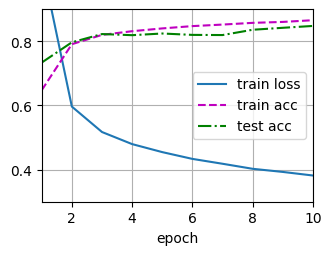

In [5]:
num_epochs,lr = 10,0.1
updater = torch.optim.SGD(params, lr=lr)
train_ch3(net, train_iter, test_iter, loss, num_epochs, updater)